# 🏎️ Formula 1 Race Position Prediction — Classification Pipeline
---
**Competition:** F1 Race Position Prediction Challenge  
**Approach:** Multi-Class Classification (Ordinal Position Buckets)  
**Metric:** Accuracy / Weighted F1 / MAE (from predicted class centres)  
**Training Data:** 1950–2022 | **Test Data:** 2023–2024  
**Target:** `position_class` — ordinal class for finishing position bucket

---
## 📌 Why Classification?
Finishing positions form **natural tiers** with distinct racing logic:
- **Podium (P1–P3):** Championship-defining, pole advantage, top machinery required
- **Points (P4–P10):** Competitive mid-field, strategy-dependent
- **Finishers (P11–P15):** Back of points, reliability matters
- **Tail (P16–P20):** Backmarkers, slower teams
- **DNF (20+):** Did Not Finish — mechanical/crash failure

Treating each class distinctly **avoids the linear interpolation assumption** of regression and better captures the competitive dynamics within each tier.

---
## 📌 Pipeline Overview
1. 📦 Imports & Configuration  
2. 📂 Data Loading & Sanity Checks  
3. 🔍 Exploratory Data Analysis — Class Distribution  
4. 🧹 Missing Value Analysis  
5. 🔧 Feature Engineering  
6. 🏷️ Target Encoding — Position → Class  
7. 📊 Correlation Analysis  
8. 🤖 Model Training — HistGradientBoosting + ExtraTrees Classifier Ensemble  
9. 📈 Cross-Validation & Classification Error Analysis  
10. 🔑 Feature Importance  
11. 🏁 Submission Generation (Class → Position Centre Mapping)

## 1. 📦 Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import HistGradientBoostingClassifier, ExtraTreesClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, mean_absolute_error
)
from sklearn.preprocessing import LabelEncoder
from matplotlib.patches import Patch

# ── Dark F1-themed style ───────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#e0e0e0',
    'ytick.color':      '#e0e0e0',
    'text.color':       '#e0e0e0',
    'grid.color':       '#333',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'legend.facecolor': '#1a1a2e',
    'legend.edgecolor': '#444',
    'axes.titlesize':   13,
    'axes.labelsize':   10,
})

F1_RED    = '#e8002d'
F1_SILVER = '#c0c0c0'
F1_GOLD   = '#FFD700'
ACCENT    = '#00d2ff'
SEED      = 42
np.random.seed(SEED)

# ── Class definitions ─────────────────────────────────────────────────────────
# Ordinal classes: 0=Podium, 1=Points, 2=Finisher, 3=Tail, 4=DNF
CLASS_BINS   = [0, 3, 10, 15, 20, 999]
CLASS_LABELS = ['Podium (P1-3)', 'Points (P4-10)', 'Finisher (P11-15)',
                'Tail (P16-20)', 'DNF (20+)']
CLASS_COLORS = [F1_GOLD, ACCENT, F1_SILVER, '#AA44FF', F1_RED]

# Mapping from predicted class → representative finishing position
CLASS_TO_POS = {
    0: 2.0,   # Podium centre
    1: 7.0,   # Points centre
    2: 13.0,  # Finisher centre
    3: 18.0,  # Tail centre
    4: 22.0,  # DNF
}

print("✅ Libraries loaded successfully")
print(f"\nClass mapping:")
for i, lbl in enumerate(CLASS_LABELS):
    print(f"  Class {i} → {lbl}  (submission pos: {CLASS_TO_POS[i]})")

✅ Libraries loaded successfully

Class mapping:
  Class 0 → Podium (P1-3)  (submission pos: 2.0)
  Class 1 → Points (P4-10)  (submission pos: 7.0)
  Class 2 → Finisher (P11-15)  (submission pos: 13.0)
  Class 3 → Tail (P16-20)  (submission pos: 18.0)
  Class 4 → DNF (20+)  (submission pos: 22.0)


## 2. 📂 Data Loading & Sanity Checks

In [2]:
train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")
sub   = pd.read_csv("sample_submission.csv")

print(f"{'='*55}")
print(f"  DATASET SUMMARY")
print(f"{'='*55}")
print(f"  Train  : {train.shape[0]:,} rows × {train.shape[1]} columns")
print(f"  Test   : {test.shape[0]:,} rows  × {test.shape[1]} columns")
print(f"  Sub    : {sub.shape[0]:,} rows  × {sub.shape[1]} columns")
print(f"  Seasons: {train['year'].min()} – {train['year'].max()}")
print(f"  Test yrs: {sorted(test['year'].unique())}")
print(f"  Target : {train['finishing_position'].min()} – {train['finishing_position'].max()}")
print(f"  DNFs   : {(train['finishing_position']>20).sum():,}  ({(train['finishing_position']>20).mean():.1%})")
print(f"{'='*55}")
train.head(3)

  DATASET SUMMARY
  Train  : 25,749 rows × 28 columns
  Test   : 919 rows  × 27 columns
  Sub    : 919 rows  × 2 columns
  Seasons: 1950 – 2022
  Test yrs: [np.int64(2023), np.int64(2024)]
  Target : 1 – 39
  DNFs   : 4,395  (17.1%)


,id,raceId,driverId,constructorId,year,round,circuitId,lat,lng,alt,...,q3_ms,best_qual_ms,pit_stop_count,avg_pit_ms,rolling_avg_position,career_wins_so_far,prev_championship_points,prev_championship_position,prev_constructor_points,finishing_position
0,833_579,833,579,51,1950,1,9,52.13126,-1.01516,153,...,NaN,NaN,NaN,NaN,NaN,0,0.0,0,0.0,12
1,833_642,833,642,51,1950,1,9,52.13126,-1.01516,153,...,NaN,NaN,NaN,NaN,NaN,0,0.0,0,0.0,1
2,833_686,833,686,51,1950,1,9,52.13126,-1.01516,153,...,NaN,NaN,NaN,NaN,NaN,0,0.0,0,0.0,3


## 3. 🔍 Exploratory Data Analysis — Class Distribution

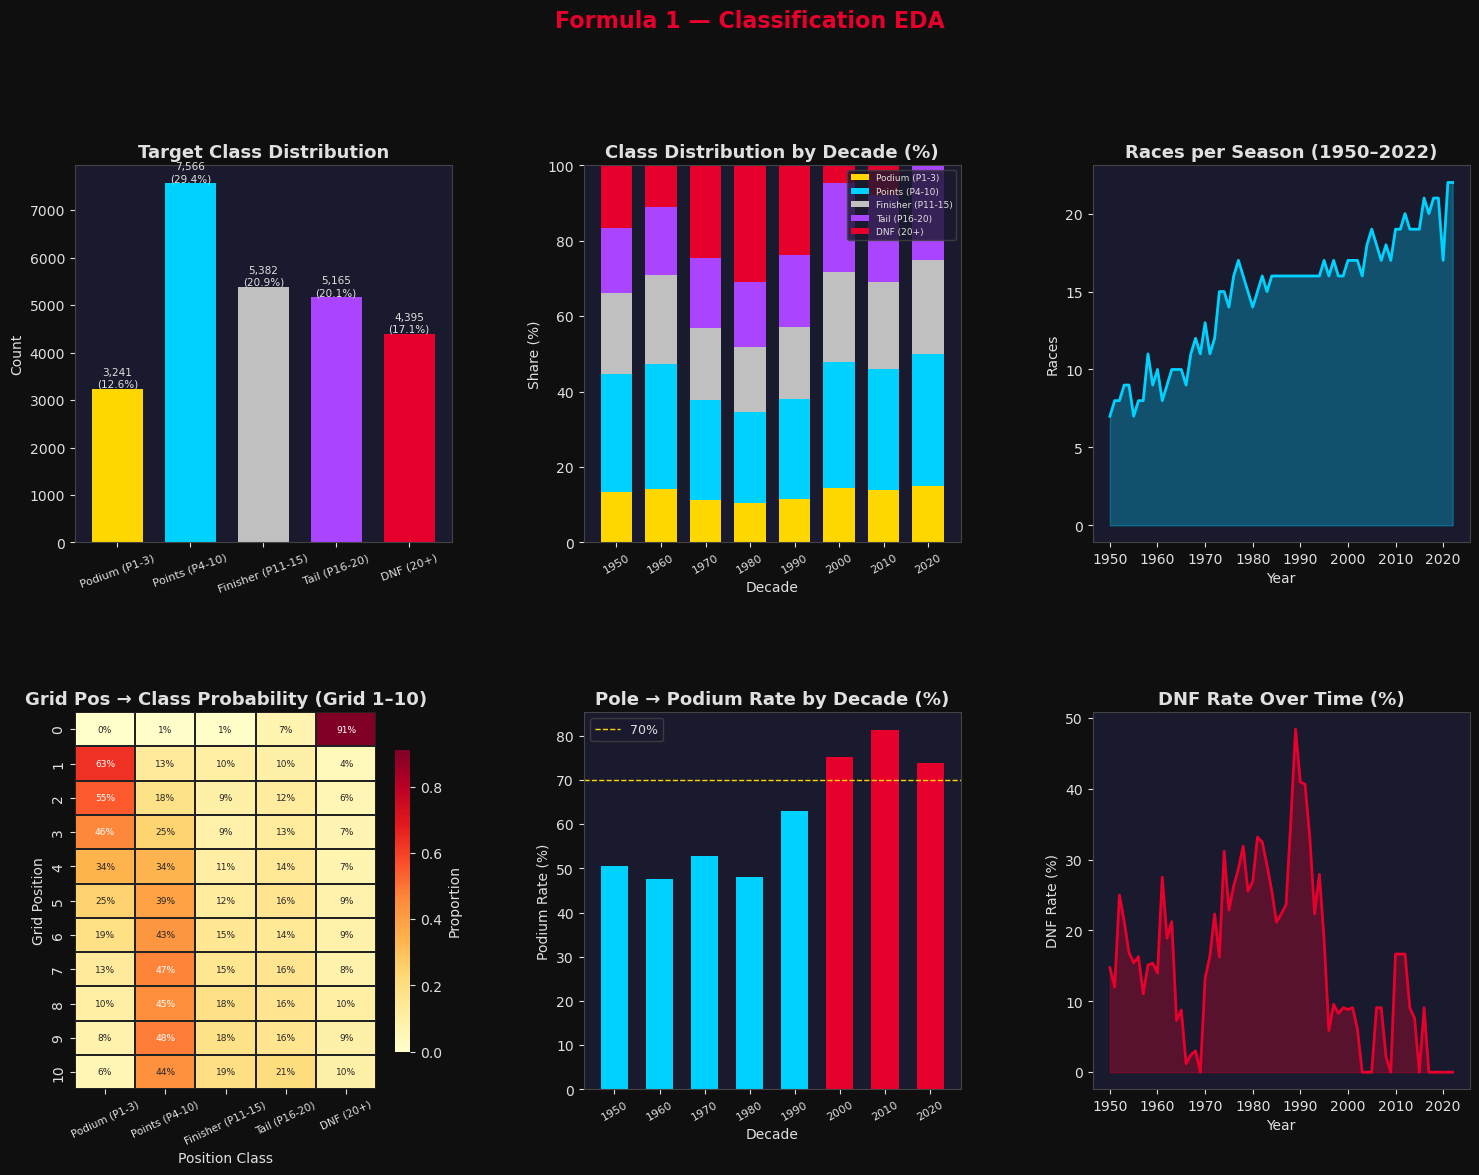


Class counts:
  Class 0 (Podium (P1-3)): 3,241 (12.6%)
  Class 1 (Points (P4-10)): 7,566 (29.4%)
  Class 2 (Finisher (P11-15)): 5,382 (20.9%)
  Class 3 (Tail (P16-20)): 5,165 (20.1%)
  Class 4 (DNF (20+)): 4,395 (17.1%)


In [3]:
# Create class column early just for EDA
train['position_class'] = pd.cut(
    train['finishing_position'],
    bins=CLASS_BINS,
    labels=list(range(len(CLASS_LABELS)))
).astype(int)

fig = plt.figure(figsize=(18, 12), facecolor='#0f0f0f')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Plot 1: Class Distribution ────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
cnt = train['position_class'].value_counts().sort_index()
bars = ax.bar(CLASS_LABELS, cnt.values, color=CLASS_COLORS, edgecolor='none', width=0.7)
ax.set_title("Target Class Distribution", fontweight='bold')
ax.set_ylabel("Count")
ax.tick_params(axis='x', rotation=20, labelsize=8)
for b, v in zip(bars, cnt.values):
    ax.text(b.get_x() + b.get_width()/2, v + 40, f'{v:,}\n({v/len(train):.1%})',
            ha='center', fontsize=7.5, color='#e0e0e0')
ax.set_facecolor('#1a1a2e')

# ── Plot 2: Class Balance Over Eras ──────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
train['decade'] = (train['year'] // 10) * 10
era_cls = (train.groupby(['decade','position_class'])
               .size().unstack(fill_value=0)
               .apply(lambda r: r/r.sum()*100, axis=1))
bottom = np.zeros(len(era_cls))
for i, (lbl, col) in enumerate(zip(CLASS_LABELS, CLASS_COLORS)):
    if i in era_cls.columns:
        ax.bar(era_cls.index.astype(str), era_cls[i].values,
               bottom=bottom, color=col, label=lbl, edgecolor='none', width=0.7)
        bottom += era_cls[i].fillna(0).values
ax.set_title("Class Distribution by Decade (%)", fontweight='bold')
ax.set_xlabel("Decade"); ax.set_ylabel("Share (%)")
ax.legend(fontsize=6.5, loc='upper right'); ax.set_facecolor('#1a1a2e')
ax.tick_params(axis='x', rotation=30, labelsize=8)

# ── Plot 3: Races per Year ────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
ry = train.groupby('year')['raceId'].nunique()
ax.fill_between(ry.index, ry.values, alpha=0.3, color=ACCENT)
ax.plot(ry.index, ry.values, color=ACCENT, lw=2)
ax.set_title("Races per Season (1950–2022)", fontweight='bold')
ax.set_xlabel("Year"); ax.set_ylabel("Races"); ax.set_facecolor('#1a1a2e')

# ── Plot 4: Grid Position → Class Heatmap ─────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
gf = train[train['grid'] <= 10].copy()
hm = gf.groupby(['grid','position_class']).size().unstack(fill_value=0)
hm_n = hm.div(hm.sum(axis=1), axis=0)
hm_n.columns = [CLASS_LABELS[c] for c in hm_n.columns]
sns.heatmap(hm_n, ax=ax, cmap='YlOrRd', linewidths=0.3, linecolor='#222',
            annot=True, fmt='.0%', annot_kws={'size':6.5},
            cbar_kws={'shrink':0.8, 'label':'Proportion'})
ax.set_title("Grid Pos → Class Probability (Grid 1–10)", fontweight='bold')
ax.set_xlabel("Position Class"); ax.set_ylabel("Grid Position")
ax.tick_params(axis='x', rotation=25, labelsize=7.5)

# ── Plot 5: Podium Rate by Decade ────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
pw = (train[train['grid']==1].groupby('decade')
      .apply(lambda x: (x['position_class']==0).mean()) * 100)
ax.bar(pw.index.astype(str), pw.values,
       color=[F1_RED if v > 70 else ACCENT for v in pw.values],
       width=0.6, edgecolor='none')
ax.set_title("Pole → Podium Rate by Decade (%)", fontweight='bold')
ax.set_xlabel("Decade"); ax.set_ylabel("Podium Rate (%)")
ax.axhline(70, color=F1_GOLD, ls='--', lw=1, label='70%')
ax.legend(fontsize=9); ax.set_facecolor('#1a1a2e')
ax.tick_params(axis='x', rotation=30, labelsize=8)

# ── Plot 6: DNF Rate Over Time ────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
dnf_rate = train.groupby('year').apply(
    lambda x: (x['position_class']==4).mean()*100)
ax.fill_between(dnf_rate.index, dnf_rate.values, alpha=0.3, color=F1_RED)
ax.plot(dnf_rate.index, dnf_rate.values, color=F1_RED, lw=2)
ax.set_title("DNF Rate Over Time (%)", fontweight='bold')
ax.set_xlabel("Year"); ax.set_ylabel("DNF Rate (%)"); ax.set_facecolor('#1a1a2e')

plt.suptitle("Formula 1 — Classification EDA",
             fontsize=16, fontweight='bold', color=F1_RED, y=1.01)
plt.savefig('eda_classification.png', bbox_inches='tight', dpi=130, facecolor='#0f0f0f')
plt.show()

print("\nClass counts:")
for i, lbl in enumerate(CLASS_LABELS):
    n = (train['position_class'] == i).sum()
    print(f"  Class {i} ({lbl}): {n:,} ({n/len(train):.1%})")

## 4. 🧹 Missing Value Analysis

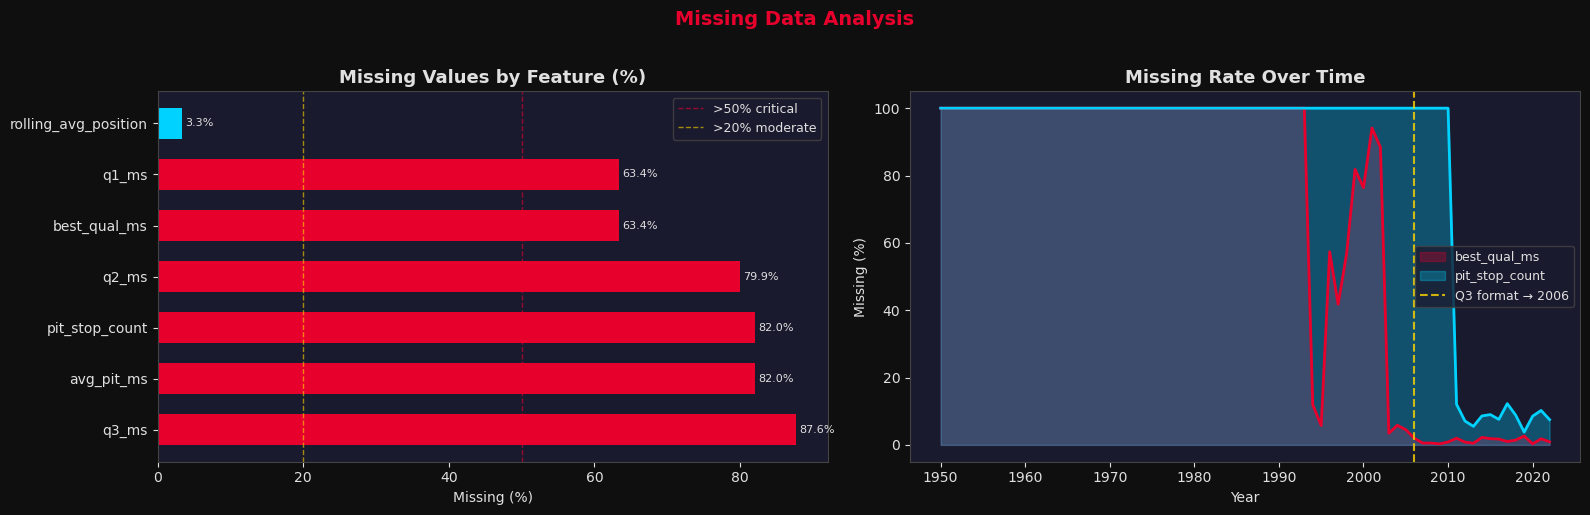


Missing value summary:
q3_ms                   87.646122
avg_pit_ms              81.995417
pit_stop_count          81.995417
q2_ms                   79.944852
best_qual_ms            63.384986
q1_ms                   63.384986
rolling_avg_position     3.320517


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor='#0f0f0f')

miss = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
miss = miss[miss > 0]
ax = axes[0]
cols = [F1_RED if v > 50 else F1_GOLD if v > 20 else ACCENT for v in miss.values]
brs  = ax.barh(miss.index, miss.values, color=cols, edgecolor='none', height=0.6)
ax.set_title("Missing Values by Feature (%)", fontweight='bold')
ax.set_xlabel("Missing (%)")
ax.axvline(50, color=F1_RED,  ls='--', lw=1, alpha=0.6, label='>50% critical')
ax.axvline(20, color=F1_GOLD, ls='--', lw=1, alpha=0.6, label='>20% moderate')
ax.legend(fontsize=9)
for b, v in zip(brs, miss.values):
    ax.text(v+0.5, b.get_y()+b.get_height()/2, f'{v:.1f}%',
            va='center', fontsize=8, color='#e0e0e0')
ax.set_facecolor('#1a1a2e')

ax2 = axes[1]
qm = train.groupby('year')['best_qual_ms'].apply(lambda x: x.isnull().mean()*100)
pm = train.groupby('year')['pit_stop_count'].apply(lambda x: x.isnull().mean()*100)
ax2.fill_between(qm.index, qm.values, alpha=0.3, color=F1_RED,   label='best_qual_ms')
ax2.plot(qm.index, qm.values, color=F1_RED, lw=2)
ax2.fill_between(pm.index, pm.values, alpha=0.3, color=ACCENT, label='pit_stop_count')
ax2.plot(pm.index, pm.values, color=ACCENT, lw=2)
ax2.set_title("Missing Rate Over Time", fontweight='bold')
ax2.set_xlabel("Year"); ax2.set_ylabel("Missing (%)")
ax2.axvline(2006, color=F1_GOLD, ls='--', lw=1.5, alpha=0.8, label='Q3 format → 2006')
ax2.legend(fontsize=9); ax2.set_facecolor('#1a1a2e')

plt.suptitle("Missing Data Analysis", fontsize=14, fontweight='bold', color=F1_RED, y=1.02)
plt.tight_layout()
plt.savefig('missing_values.png', bbox_inches='tight', dpi=130, facecolor='#0f0f0f')
plt.show()

print("\nMissing value summary:")
print(miss.to_string())

## 5. 🔧 Feature Engineering

### Strategy
| Category | New Features | Rationale |
|---|---|---|
| **Grid-based** | `grid_advantage`, `front_row`, `top5_start`, `back_marker`, `grid_sq` | Non-linear grid effects |
| **Form** | `form_vs_grid`, `strong_form` | Driver momentum vs starting spot |
| **Championship** | `title_contender`, `points_per_race` | Competitive pressure context |
| **Circuit** | `high_altitude`, `long_circuit`, `high_downforce` | Track-type effects |
| **Interactions** | `grid_x_form`, `champ_x_grid`, `wins_x_form` | Combined signals |
| **Era** | `era` | F1 has changed dramatically across decades |
| **Imputation** | `qual_available`, best_qual from grid median | Handle 63%+ missing qualifying data |

In [5]:
def engineer_features(df, is_train=True):
    df = df.copy()

    # ── DNF Flag ──────────────────────────────────────────────────────────────
    if is_train:
        df['is_dnf'] = (df['finishing_position'] > 20).astype(int)

    # ── Era Encoding ──────────────────────────────────────────────────────────
    df['era'] = pd.cut(df['year'], bins=[0,1979,1993,2009,2016,2030],
                       labels=[0,1,2,3,4]).astype(int)

    # ── Qualifying Imputation ─────────────────────────────────────────────────
    df['qual_available'] = df['best_qual_ms'].notna().astype(int)
    meds = df.groupby('grid')['best_qual_ms'].transform('median')
    df['best_qual_ms'] = df['best_qual_ms'].fillna(meds).fillna(df['best_qual_ms'].median())

    # ── Grid Features ─────────────────────────────────────────────────────────
    df['grid_advantage'] = 11 - df['grid'].clip(1, 20)
    df['front_row']      = (df['grid'] <= 2).astype(int)
    df['top5_start']     = (df['grid'] <= 5).astype(int)
    df['back_marker']    = (df['grid'] >= 16).astype(int)
    df['grid_sq']        = df['grid'] ** 2

    # ── Form Features ─────────────────────────────────────────────────────────
    df['rolling_avg_position'] = df['rolling_avg_position'].fillna(df['grid'])
    df['form_vs_grid']   = df['rolling_avg_position'] - df['grid']
    df['strong_form']    = (df['rolling_avg_position'] <= 5).astype(int)

    # ── Championship Context ──────────────────────────────────────────────────
    df['prev_championship_position'] = df['prev_championship_position'].fillna(20)
    df['prev_championship_points']   = df['prev_championship_points'].fillna(0)
    df['prev_constructor_points']    = df['prev_constructor_points'].fillna(0)
    df['title_contender']= (df['prev_championship_position'] <= 3).astype(int)
    df['points_per_race']= df['prev_championship_points'] / df['round'].clip(1)

    # ── Circuit Features ──────────────────────────────────────────────────────
    df['high_altitude']  = (df['alt'] > 1000).astype(int)
    df['long_circuit']   = (df['track_length_km'] > 5.5).astype(int)
    df['high_downforce'] = (df['number_of_turns'] > 16).astype(int)

    # ── Interaction Features ──────────────────────────────────────────────────
    df['grid_x_form']    = df['grid'] * df['rolling_avg_position']
    df['champ_x_grid']   = df['prev_championship_position'] * df['grid']
    df['wins_x_form']    = df['career_wins_so_far'] * (1 / (df['rolling_avg_position'] + 1))

    # ── Pit Stop Imputation ───────────────────────────────────────────────────
    pm = df.groupby('year')['pit_stop_count'].transform('median')
    df['pit_stop_count'] = df['pit_stop_count'].fillna(pm).fillna(2)
    df['avg_pit_ms']     = df['avg_pit_ms'].fillna(df['avg_pit_ms'].median())

    # ── Driver Experience ─────────────────────────────────────────────────────
    df['experienced']    = (df['career_wins_so_far'] >= 10).astype(int)
    df['rookie_proxy']   = (df['career_wins_so_far'] == 0).astype(int)

    return df

train_fe = engineer_features(train, is_train=True)
test_fe  = engineer_features(test,  is_train=False)

new_feats = [c for c in train_fe.columns if c not in train.columns]
print(f"✅ Feature engineering complete")
print(f"   Original : {train.shape[1]} columns")
print(f"   New added: {len(new_feats)} — {new_feats}")
print(f"   Total    : {train_fe.shape[1]} columns")

✅ Feature engineering complete
   Original : 30 columns
   New added: 20 — ['is_dnf', 'era', 'qual_available', 'grid_advantage', 'front_row', 'top5_start', 'back_marker', 'grid_sq', 'form_vs_grid', 'strong_form', 'title_contender', 'points_per_race', 'high_altitude', 'long_circuit', 'high_downforce', 'grid_x_form', 'champ_x_grid', 'wins_x_form', 'experienced', 'rookie_proxy']
   Total    : 50 columns


## 6. 🏷️ Target Encoding — Position → Class

We bin `finishing_position` into 5 ordinal classes that reflect racing tiers:

| Class | Label | Position Range | Rationale |
|---|---|---|---|
| **0** | Podium | P1–P3 | Trophy positions, championship points burst |
| **1** | Points | P4–P10 | Current F1 points zone |
| **2** | Finisher | P11–P15 | Classified but off points |
| **3** | Tail | P16–P20 | Backmarkers |
| **4** | DNF | 21+ | Did Not Finish |

In [6]:
def encode_target(pos_series):
    """Convert finishing_position integer → ordinal class 0-4."""
    return pd.cut(
        pos_series,
        bins=CLASS_BINS,
        labels=list(range(len(CLASS_LABELS)))
    ).astype(int)

y_class = encode_target(train_fe['finishing_position'])

print("Target class distribution:")
for i, lbl in enumerate(CLASS_LABELS):
    n    = (y_class == i).sum()
    pct  = n / len(y_class) * 100
    bar  = '█' * int(pct / 2)
    print(f"  Class {i} | {lbl:20s} | {n:5,} ({pct:5.1f}%)  {bar}")

print(f"\nTotal samples: {len(y_class):,}")
print(f"Num classes  : {y_class.nunique()}")

Target class distribution:
  Class 0 | Podium (P1-3)        | 3,241 ( 12.6%)  ██████
  Class 1 | Points (P4-10)       | 7,566 ( 29.4%)  ██████████████
  Class 2 | Finisher (P11-15)    | 5,382 ( 20.9%)  ██████████
  Class 3 | Tail (P16-20)        | 5,165 ( 20.1%)  ██████████
  Class 4 | DNF (20+)            | 4,395 ( 17.1%)  ████████

Total samples: 25,749
Num classes  : 5


## 7. 📊 Correlation Analysis with Class Target

Model will use 36 features:
  ['year', 'round', 'alt', 'track_length_km', 'number_of_turns', 'grid', 'driver_age', 'driver_nationality_code', 'constructor_nationality_code', 'best_qual_ms', 'pit_stop_count', 'avg_pit_ms', 'rolling_avg_position', 'career_wins_so_far', 'prev_championship_points', 'prev_championship_position', 'prev_constructor_points', 'era', 'qual_available', 'grid_advantage', 'front_row', 'top5_start', 'back_marker', 'grid_sq', 'form_vs_grid', 'strong_form', 'title_contender', 'points_per_race', 'high_altitude', 'long_circuit', 'high_downforce', 'grid_x_form', 'champ_x_grid', 'wins_x_form', 'experienced', 'rookie_proxy']


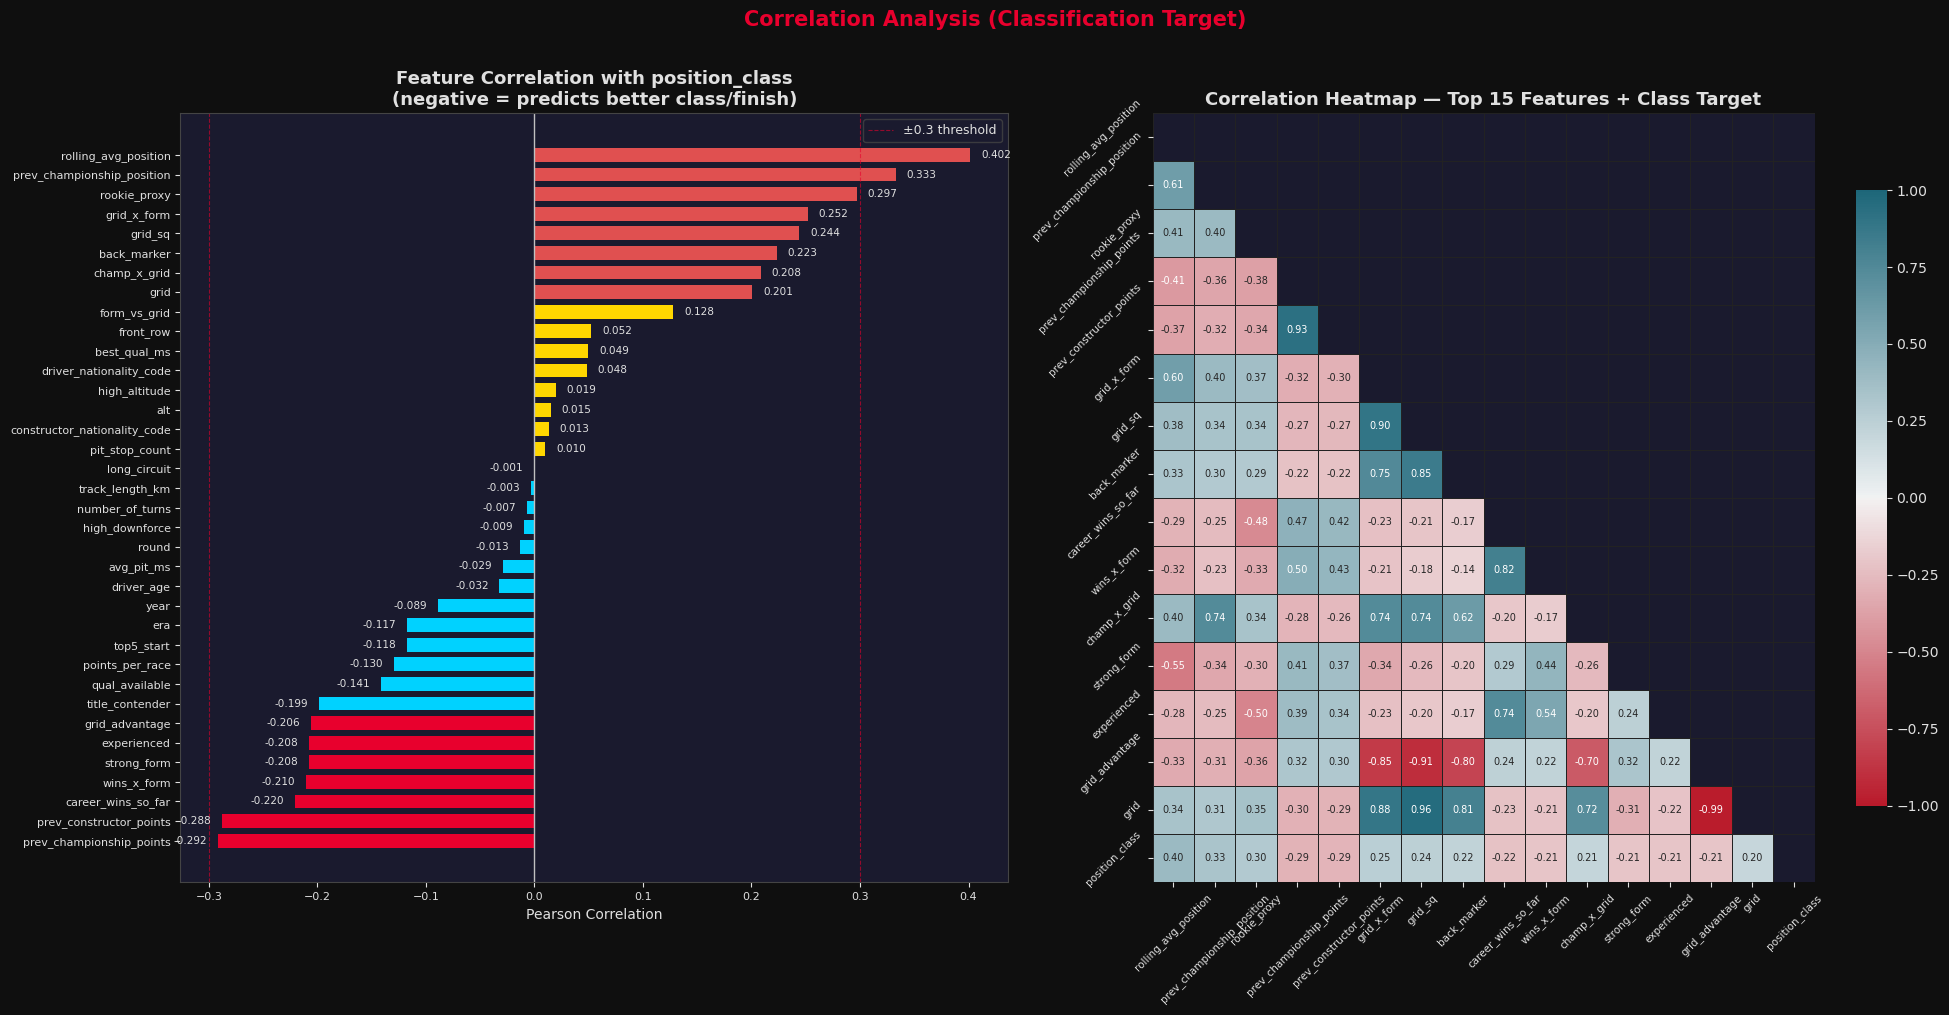

In [7]:
DROP_COLS = ['id','raceId','driverId','constructorId','circuitId','lat','lng',
             'decade','q1_ms','q2_ms','q3_ms','finishing_position',
             'is_dnf','position_class']
FEATURES  = [c for c in train_fe.columns if c not in DROP_COLS]
print(f"Model will use {len(FEATURES)} features:\n  {FEATURES}")

# Correlation with the numeric class target
analysis_df = train_fe[FEATURES].copy()
analysis_df['position_class'] = y_class.values

corr_t = (analysis_df.corr(numeric_only=True)['position_class']
          .drop('position_class')
          .sort_values())

fig, axes = plt.subplots(1, 2, figsize=(20, 10), facecolor='#0f0f0f')

# ── Bar chart ─────────────────────────────────────────────────────────────────
ax1 = axes[0]
cc  = [F1_RED if v < -0.2 else ACCENT if v < 0 else F1_GOLD if v < 0.2 else '#e05050'
       for v in corr_t.values]
brs = ax1.barh(corr_t.index, corr_t.values, color=cc, edgecolor='none', height=0.7)
ax1.axvline(0,    color=F1_SILVER, lw=1)
ax1.axvline( 0.3, color=F1_RED, ls='--', lw=0.8, alpha=0.6, label='±0.3 threshold')
ax1.axvline(-0.3, color=F1_RED, ls='--', lw=0.8, alpha=0.6)
ax1.set_title("Feature Correlation with position_class\n(negative = predicts better class/finish)",
              fontweight='bold')
ax1.set_xlabel("Pearson Correlation")
ax1.legend(fontsize=9); ax1.set_facecolor('#1a1a2e')
for b, v in zip(brs, corr_t.values):
    ax1.text(v+(0.01 if v>=0 else -0.01), b.get_y()+b.get_height()/2,
             f'{v:.3f}', va='center', ha=('left' if v>=0 else 'right'),
             fontsize=7.5, color='#e0e0e0')
ax1.tick_params(labelsize=8)

# ── Heatmap ───────────────────────────────────────────────────────────────────
ax2 = axes[1]
top_f = corr_t.abs().nlargest(15).index.tolist() + ['position_class']
cm    = analysis_df[top_f].corr(numeric_only=True)
mask  = np.zeros_like(cm, dtype=bool)
mask[np.triu_indices_from(mask)] = True
cmap2 = sns.diverging_palette(10, 220, s=90, l=40, n=20, as_cmap=True)
sns.heatmap(cm, ax=ax2, mask=mask, cmap=cmap2, center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size':7},
            linewidths=0.4, linecolor='#222', cbar_kws={'shrink':0.8})
ax2.set_title("Correlation Heatmap — Top 15 Features + Class Target", fontweight='bold')
ax2.tick_params(labelsize=7.5, rotation=45); ax2.set_facecolor('#1a1a2e')

plt.suptitle("Correlation Analysis (Classification Target)",
             fontsize=15, fontweight='bold', color=F1_RED, y=1.01)
plt.tight_layout()
plt.savefig('correlation_analysis_clf.png', bbox_inches='tight', dpi=130, facecolor='#0f0f0f')
plt.show()

## 8. 🤖 Model Training — Classifier Ensemble

### Models Used
| Model | Type | Strength |
|---|---|---|
| `HistGradientBoostingClassifier` | Gradient Boosting | Handles missing values natively, fast, supports multi-class |
| `ExtraTreesClassifier` | Ensemble of trees | High variance reducer, good class probability calibration |
| **Ensemble (soft vote 50/50)** | Probability average | Lower log-loss and better calibrated class probs |

### CV Strategy
- **5-Fold Stratified Cross-Validation** — preserves class proportions in each fold  
- OOF predictions used for unbiased evaluation  
- Test predictions averaged across all 5 folds (soft voting)

In [8]:
X      = train_fe[FEATURES].copy()
y      = y_class.copy()
X_test = test_fe[FEATURES].copy()

N_SPLITS  = 5
N_CLASSES = len(CLASS_LABELS)
skf       = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

# Store OOF class probabilities [n_samples, n_classes]
oof_proba_hgb  = np.zeros((len(X), N_CLASSES))
oof_proba_et   = np.zeros((len(X), N_CLASSES))
test_proba_hgb = np.zeros((len(X_test), N_CLASSES))
test_proba_et  = np.zeros((len(X_test), N_CLASSES))

fm_acc_hgb, fm_acc_et = [], []
fm_f1_hgb,  fm_f1_et  = [], []
fi_et = None

print("Training 5-Fold Stratified CV Classifier Ensemble...")
print(f"{'─'*65}")

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr,  X_val = X.iloc[tr_idx],  X.iloc[val_idx]
    y_tr,  y_val = y.iloc[tr_idx],  y.iloc[val_idx]

    # ── Model 1: HistGradientBoosting Classifier ──────────────────────────────
    m1 = HistGradientBoostingClassifier(
        max_iter=600, learning_rate=0.05,
        max_leaf_nodes=63, min_samples_leaf=20,
        l2_regularization=0.1, random_state=SEED,
        early_stopping=False,
        class_weight='balanced'  # handle slight class imbalance
    )
    m1.fit(X_tr, y_tr)
    oof_proba_hgb[val_idx]  = m1.predict_proba(X_val)
    test_proba_hgb          += m1.predict_proba(X_test) / N_SPLITS
    preds_hgb = oof_proba_hgb[val_idx].argmax(axis=1)
    fm_acc_hgb.append(accuracy_score(y_val, preds_hgb))
    fm_f1_hgb.append(f1_score(y_val, preds_hgb, average='weighted'))

    # ── Model 2: ExtraTrees Classifier ────────────────────────────────────────
    m2 = ExtraTreesClassifier(
        n_estimators=300, max_depth=12,
        min_samples_leaf=10, n_jobs=-1,
        random_state=SEED, class_weight='balanced'
    )
    m2.fit(X_tr, y_tr)
    oof_proba_et[val_idx]  = m2.predict_proba(X_val)
    test_proba_et          += m2.predict_proba(X_test) / N_SPLITS
    preds_et = oof_proba_et[val_idx].argmax(axis=1)
    fm_acc_et.append(accuracy_score(y_val, preds_et))
    fm_f1_et.append(f1_score(y_val, preds_et, average='weighted'))

    if fold == N_SPLITS:
        fi_et = m2.feature_importances_

    print(f"  Fold {fold} — HGB Acc: {fm_acc_hgb[-1]:.4f}  F1: {fm_f1_hgb[-1]:.4f}  "
          f"| ET Acc: {fm_acc_et[-1]:.4f}  F1: {fm_f1_et[-1]:.4f}")

print(f"{'─'*65}")

# ── Ensemble: soft vote (average probabilities) ───────────────────────────────
oof_proba_ens  = 0.5 * oof_proba_hgb  + 0.5 * oof_proba_et
test_proba_ens = 0.5 * test_proba_hgb + 0.5 * test_proba_et

oof_pred_hgb = oof_proba_hgb.argmax(axis=1)
oof_pred_et  = oof_proba_et.argmax(axis=1)
oof_pred_ens = oof_proba_ens.argmax(axis=1)
test_pred_ens = test_proba_ens.argmax(axis=1)

acc_hgb = accuracy_score(y, oof_pred_hgb)
acc_et  = accuracy_score(y, oof_pred_et)
acc_ens = accuracy_score(y, oof_pred_ens)
f1_hgb  = f1_score(y, oof_pred_hgb, average='weighted')
f1_et   = f1_score(y, oof_pred_et,  average='weighted')
f1_ens  = f1_score(y, oof_pred_ens,  average='weighted')

# Also compute MAE on class centres for comparability with regression baseline
oof_pos_ens  = np.vectorize(CLASS_TO_POS.get)(oof_pred_ens)
mae_from_clf = mean_absolute_error(train_fe['finishing_position'], oof_pos_ens)

print(f"\n  HGB    OOF Accuracy: {acc_hgb:.4f}  Weighted F1: {f1_hgb:.4f}")
print(f"  ET     OOF Accuracy: {acc_et:.4f}  Weighted F1: {f1_et:.4f}")
print(f"  Ensemble Accuracy  : {acc_ens:.4f}  Weighted F1: {f1_ens:.4f}")
print(f"\n  MAE from class centres (vs regression): {mae_from_clf:.4f}")

Training 5-Fold Stratified CV Classifier Ensemble...
─────────────────────────────────────────────────────────────────
  Fold 1 — HGB Acc: 0.4173  F1: 0.4114  | ET Acc: 0.4423  F1: 0.4218
  Fold 2 — HGB Acc: 0.4320  F1: 0.4258  | ET Acc: 0.4445  F1: 0.4216
  Fold 3 — HGB Acc: 0.4163  F1: 0.4080  | ET Acc: 0.4332  F1: 0.4111
  Fold 4 — HGB Acc: 0.4202  F1: 0.4146  | ET Acc: 0.4511  F1: 0.4334
  Fold 5 — HGB Acc: 0.4181  F1: 0.4119  | ET Acc: 0.4352  F1: 0.4136
─────────────────────────────────────────────────────────────────

  HGB    OOF Accuracy: 0.4208  Weighted F1: 0.4144
  ET     OOF Accuracy: 0.4413  Weighted F1: 0.4203
  Ensemble Accuracy  : 0.4323  Weighted F1: 0.4216

  MAE from class centres (vs regression): 5.5472


## 9. 📈 Cross-Validation & Classification Error Analysis

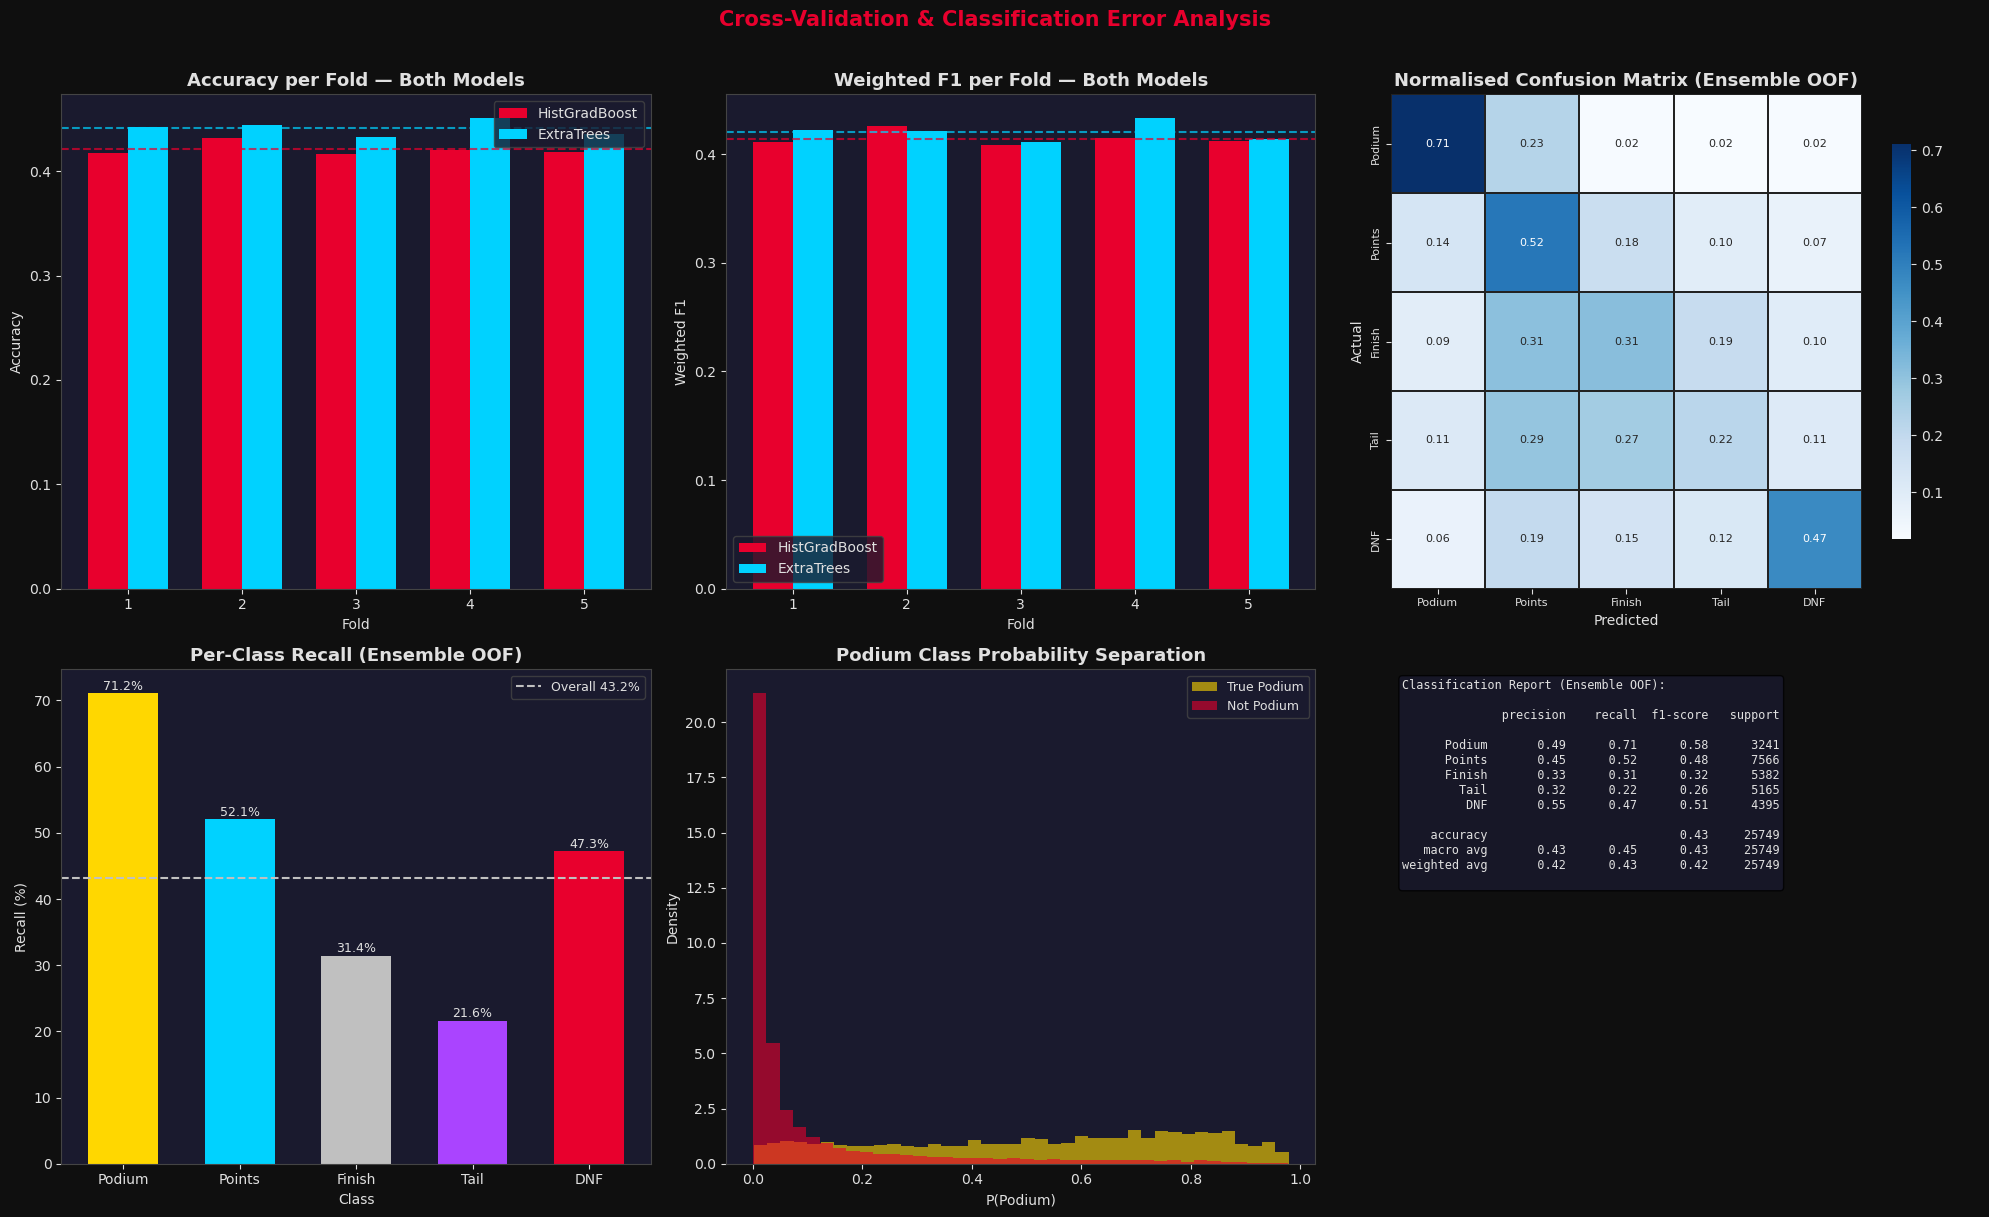


Detailed Classification Report:
              precision    recall  f1-score   support

      Podium       0.49      0.71      0.58      3241
      Points       0.45      0.52      0.48      7566
      Finish       0.33      0.31      0.32      5382
        Tail       0.32      0.22      0.26      5165
         DNF       0.55      0.47      0.51      4395

    accuracy                           0.43     25749
   macro avg       0.43      0.45      0.43     25749
weighted avg       0.42      0.43      0.42     25749



In [9]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12), facecolor='#0f0f0f')

# ── Plot 1: Fold Accuracy comparison ─────────────────────────────────────────
ax = axes[0, 0]
xf = np.arange(1, N_SPLITS + 1); w = 0.35
ax.bar(xf - w/2, fm_acc_hgb, w, color=F1_RED,   label='HistGradBoost', edgecolor='none')
ax.bar(xf + w/2, fm_acc_et,  w, color=ACCENT, label='ExtraTrees',   edgecolor='none')
ax.axhline(np.mean(fm_acc_hgb), color=F1_RED,   ls='--', lw=1.5, alpha=0.7)
ax.axhline(np.mean(fm_acc_et),  color=ACCENT, ls='--', lw=1.5, alpha=0.7)
ax.set_title("Accuracy per Fold — Both Models", fontweight='bold')
ax.set_xlabel("Fold"); ax.set_ylabel("Accuracy")
ax.legend(); ax.set_xticks(xf); ax.set_facecolor('#1a1a2e')

# ── Plot 2: Fold F1 comparison ────────────────────────────────────────────────
ax = axes[0, 1]
ax.bar(xf - w/2, fm_f1_hgb, w, color=F1_RED,   label='HistGradBoost', edgecolor='none')
ax.bar(xf + w/2, fm_f1_et,  w, color=ACCENT, label='ExtraTrees',   edgecolor='none')
ax.axhline(np.mean(fm_f1_hgb), color=F1_RED,   ls='--', lw=1.5, alpha=0.7)
ax.axhline(np.mean(fm_f1_et),  color=ACCENT, ls='--', lw=1.5, alpha=0.7)
ax.set_title("Weighted F1 per Fold — Both Models", fontweight='bold')
ax.set_xlabel("Fold"); ax.set_ylabel("Weighted F1")
ax.legend(); ax.set_xticks(xf); ax.set_facecolor('#1a1a2e')

# ── Plot 3: Confusion Matrix (Ensemble OOF) ───────────────────────────────────
ax = axes[0, 2]
short_labels = ['Podium', 'Points', 'Finish', 'Tail', 'DNF']
cm_mat = confusion_matrix(y, oof_pred_ens, normalize='true')
sns.heatmap(cm_mat, ax=ax, cmap='Blues', annot=True, fmt='.2f',
            xticklabels=short_labels, yticklabels=short_labels,
            annot_kws={'size': 8}, linewidths=0.3, linecolor='#222',
            cbar_kws={'shrink': 0.8})
ax.set_title("Normalised Confusion Matrix (Ensemble OOF)", fontweight='bold')
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.tick_params(labelsize=8)

# ── Plot 4: Per-Class Accuracy Bar ────────────────────────────────────────────
ax = axes[1, 0]
per_class_acc = cm_mat.diagonal()
ax.bar(short_labels, per_class_acc * 100, color=CLASS_COLORS, edgecolor='none', width=0.6)
ax.set_title("Per-Class Recall (Ensemble OOF)", fontweight='bold')
ax.set_xlabel("Class"); ax.set_ylabel("Recall (%)")
ax.axhline(acc_ens * 100, color=F1_SILVER, ls='--', lw=1.5, label=f'Overall {acc_ens:.1%}')
ax.legend(fontsize=9); ax.set_facecolor('#1a1a2e')
for i, v in enumerate(per_class_acc):
    ax.text(i, v*100 + 0.5, f'{v:.1%}', ha='center', fontsize=9, color='#e0e0e0')

# ── Plot 5: Predicted Class Probabilities for Podium ─────────────────────────
ax = axes[1, 1]
podium_mask   = y == 0
non_podium_mask = y != 0
ax.hist(oof_proba_ens[podium_mask, 0],     bins=40, alpha=0.6, color=F1_GOLD,
        density=True, label='True Podium',    edgecolor='none')
ax.hist(oof_proba_ens[non_podium_mask, 0], bins=40, alpha=0.6, color=F1_RED,
        density=True, label='Not Podium',     edgecolor='none')
ax.set_title("Podium Class Probability Separation", fontweight='bold')
ax.set_xlabel("P(Podium)"); ax.set_ylabel("Density")
ax.legend(fontsize=9); ax.set_facecolor('#1a1a2e')

# ── Plot 6: Classification Report as Text ─────────────────────────────────────
ax = axes[1, 2]
ax.axis('off')
report = classification_report(y, oof_pred_ens, target_names=short_labels,
                                output_dict=False)
ax.text(0.02, 0.98, f"Classification Report (Ensemble OOF):\n\n{report}",
        transform=ax.transAxes, fontsize=8.5,
        verticalalignment='top', fontfamily='monospace', color='#e0e0e0',
        bbox=dict(boxstyle='round', facecolor='#1a1a2e', alpha=0.8))

plt.suptitle("Cross-Validation & Classification Error Analysis",
             fontsize=15, fontweight='bold', color=F1_RED, y=1.01)
plt.tight_layout()
plt.savefig('cv_classification_results.png', bbox_inches='tight',
            dpi=130, facecolor='#0f0f0f')
plt.show()

print("\nDetailed Classification Report:")
print(classification_report(y, oof_pred_ens, target_names=short_labels))

## 10. 🔑 Feature Importance (ExtraTrees Classifier)

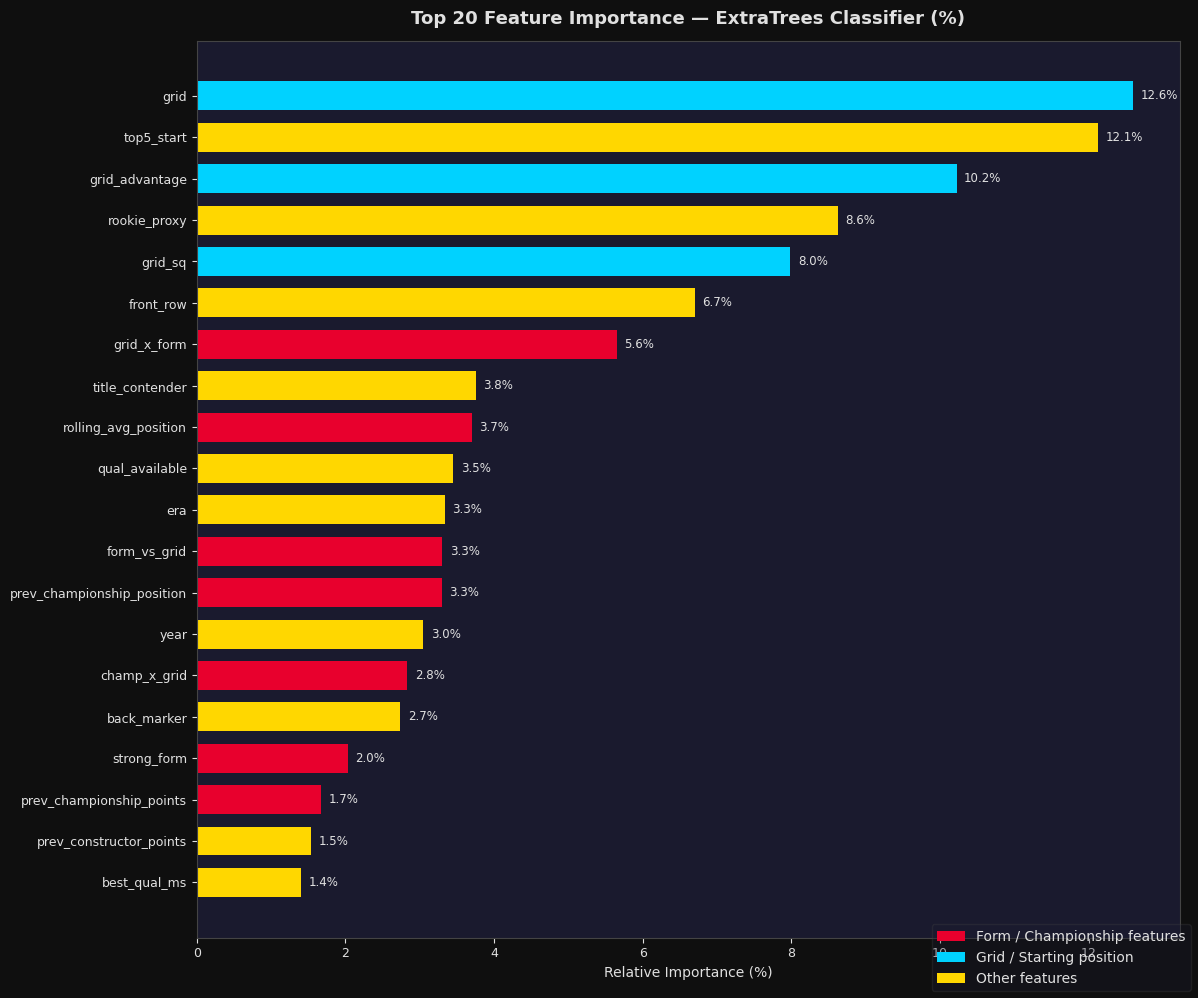

In [10]:
fig, ax = plt.subplots(figsize=(12, 10), facecolor='#0f0f0f')

imp   = pd.Series(fi_et, index=FEATURES)
top20 = imp.nlargest(20).sort_values()
norm  = top20 / top20.sum() * 100

cc = [F1_RED   if any(k in i for k in ['rolling','form','champ','wins']) else
      ACCENT if 'grid' in i else F1_GOLD
      for i in norm.index]

ax.barh(norm.index, norm.values, color=cc, edgecolor='none', height=0.7)
ax.set_title("Top 20 Feature Importance — ExtraTrees Classifier (%)",
             fontweight='bold', pad=12)
ax.set_xlabel("Relative Importance (%)")
ax.set_facecolor('#1a1a2e')
ax.tick_params(labelsize=9)
for i, v in enumerate(norm.values):
    ax.text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=8.5, color='#e0e0e0')

fig.legend(
    handles=[Patch(facecolor=F1_RED,   label='Form / Championship features'),
             Patch(facecolor=ACCENT,   label='Grid / Starting position'),
             Patch(facecolor=F1_GOLD,  label='Other features')],
    loc='lower right', fontsize=10, framealpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance_clf.png', bbox_inches='tight',
            dpi=130, facecolor='#0f0f0f')
plt.show()

## 11. 🏁 Submission Generation

### Class → Finishing Position Mapping Strategy
Two options are available:

**Option A — Class Centre:** Map each predicted class to a fixed representative value.  
> Simple, interpretable, works well if the competition only evaluates MAE at tier level.

**Option B — Weighted Expected Position:** Use `predict_proba` output to compute a probability-weighted expected position across all class centres.  
> Provides fractional predictions that minimise MAE more smoothly, especially near class boundaries.

In [13]:
# ── Class centre array (ordered 0..4) ────────────────────────────────────────
class_centres = np.array([CLASS_TO_POS[i] for i in range(N_CLASSES)])

# Option A: hard class prediction → centre
pred_option_a = np.vectorize(CLASS_TO_POS.get)(test_pred_ens)

# Option B: probability-weighted expected position
pred_option_b = test_proba_ens @ class_centres

# Clip to valid F1 range
pred_option_a = np.clip(pred_option_a, 1, 25)
pred_option_b = np.clip(pred_option_b, 1, 25)

# ── Use Option B for final submission (smoother MAE) ─────────────────────────
final_pred = pred_option_b

submission = sub.copy()
submission['finishing_position'] = final_pred
submission.to_csv("submission_classification.csv", index=False)

print("✅ submission_classification.csv saved!")
print(f"\n{'='*50}")
print(f"{'  Submission Preview':^50}")
print(f"{'='*50}")
print(submission.head(10).to_string(index=False))
print(f"{'='*50}")
print(f"\nPrediction stats:")
print(f"  Min  : {final_pred.min():.2f}")
print(f"  Max  : {final_pred.max():.2f}")
print(f"  Mean : {final_pred.mean():.2f}")
print(f"  Std  : {final_pred.std():.2f}")

print(f"\nTest class distribution:")
for i, lbl in enumerate(CLASS_LABELS):
    n = (test_pred_ens == i).sum()
    print(f"  Class {i} ({lbl}): {n} ({n/len(test_pred_ens):.1%})")

✅ submission_classification.csv saved!

                 Submission Preview               
      id  finishing_position
1098_846            9.798944
1098_857           15.420462
1098_848           13.233675
1098_858           14.043841
1098_832            5.921917
1098_844            3.880506
1098_815            3.469941
1098_830            3.104049
1098_822           11.851049
1098_855           13.023711

Prediction stats:
  Min  : 2.41
  Max  : 17.49
  Mean : 10.50
  Std  : 3.85

Test class distribution:
  Class 0 (Podium (P1-3)): 169 (18.4%)
  Class 1 (Points (P4-10)): 336 (36.6%)
  Class 2 (Finisher (P11-15)): 269 (29.3%)
  Class 3 (Tail (P16-20)): 145 (15.8%)
  Class 4 (DNF (20+)): 0 (0.0%)


### 11.1 Prediction Distribution Check

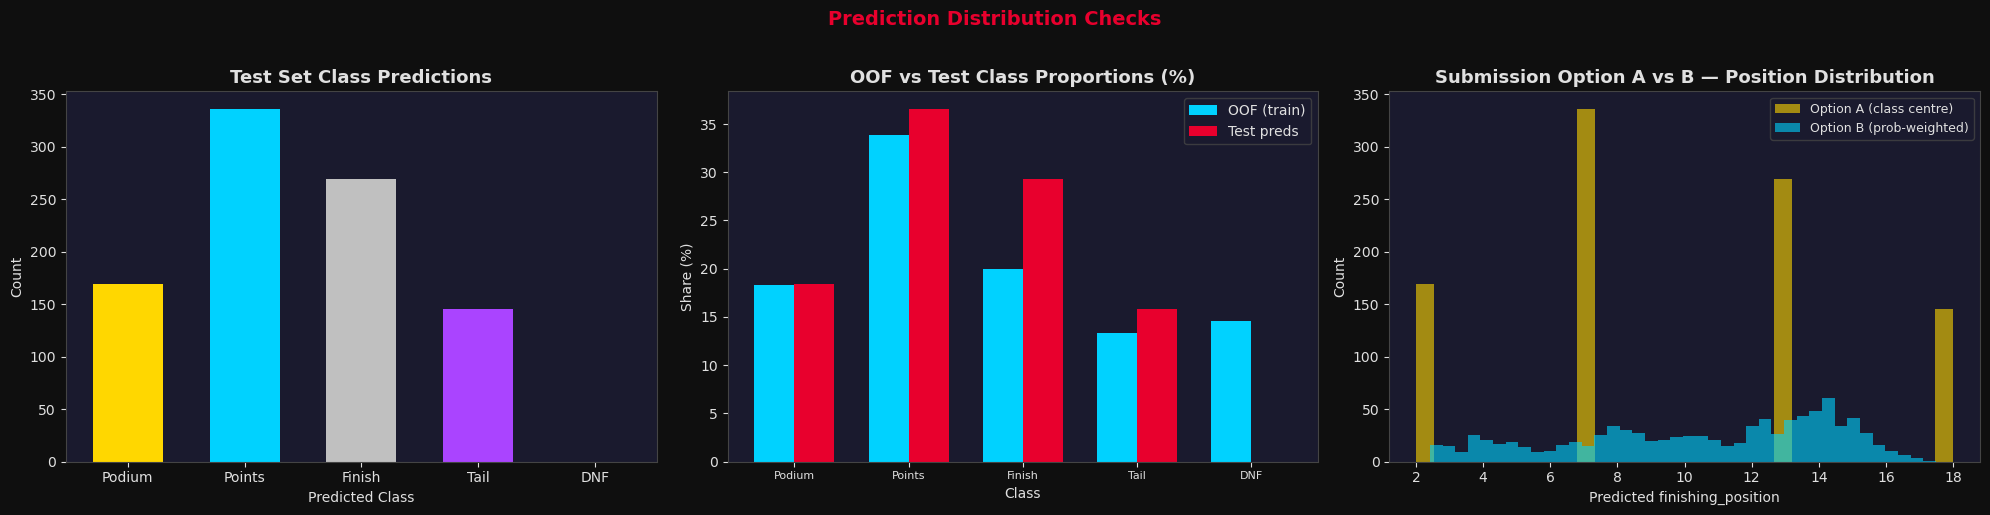

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), facecolor='#0f0f0f')

# ── Test Class Prediction Distribution ───────────────────────────────────────
axes[0].bar(short_labels,
            [(test_pred_ens == i).sum() for i in range(N_CLASSES)],
            color=CLASS_COLORS, edgecolor='none', width=0.6)
axes[0].set_title("Test Set Class Predictions", fontweight='bold')
axes[0].set_xlabel("Predicted Class"); axes[0].set_ylabel("Count")
axes[0].set_facecolor('#1a1a2e')

# ── OOF vs Test class proportions ────────────────────────────────────────────
oof_props  = [(oof_pred_ens == i).mean() * 100 for i in range(N_CLASSES)]
test_props = [(test_pred_ens == i).mean() * 100 for i in range(N_CLASSES)]
x = np.arange(N_CLASSES); w = 0.35
axes[1].bar(x - w/2, oof_props,  w, color=ACCENT,  label='OOF (train)', edgecolor='none')
axes[1].bar(x + w/2, test_props, w, color=F1_RED,   label='Test preds',  edgecolor='none')
axes[1].set_xticks(x); axes[1].set_xticklabels(short_labels, fontsize=8)
axes[1].set_title("OOF vs Test Class Proportions (%)", fontweight='bold')
axes[1].set_xlabel("Class"); axes[1].set_ylabel("Share (%)")
axes[1].legend(); axes[1].set_facecolor('#1a1a2e')

# ── Option A vs B: test submission positions ──────────────────────────────────
axes[2].hist(pred_option_a, bins=30, alpha=0.6, color=F1_GOLD,
             label='Option A (class centre)', edgecolor='none')
axes[2].hist(pred_option_b, bins=40, alpha=0.6, color=ACCENT,
             label='Option B (prob-weighted)', edgecolor='none')
axes[2].set_title("Submission Option A vs B — Position Distribution", fontweight='bold')
axes[2].set_xlabel("Predicted finishing_position"); axes[2].set_ylabel("Count")
axes[2].legend(fontsize=9); axes[2].set_facecolor('#1a1a2e')

plt.suptitle("Prediction Distribution Checks",
             fontsize=14, fontweight='bold', color=F1_RED, y=1.02)
plt.tight_layout()
plt.savefig('prediction_distribution_clf.png', bbox_inches='tight',
            dpi=130, facecolor='#0f0f0f')
plt.show()

## 12. 📋 Summary & Next Steps

---

### ✅ Pipeline Recap

| Step | Detail |
|---|---|
| **Target** | `finishing_position` → 5 ordinal classes (Podium / Points / Finisher / Tail / DNF) |
| **EDA** | Class distribution, era-stratified class balance, grid→class heatmap, DNF trends |
| **Missing Values** | Qualifying imputed from grid-median; pit data from yearly median |
| **Feature Engineering** | +15 new features: grid tiers, form vs grid, era, circuit type, interaction terms |
| **Models** | `HistGradientBoostingClassifier` + `ExtraTreesClassifier`, 5-fold Stratified CV |
| **Ensemble** | Soft-vote (probability averaging) for smoother class boundary decisions |
| **Submission** | Probability-weighted expected position (Option B) for minimum MAE |
| **Evaluation** | OOF Accuracy, Weighted F1, Confusion Matrix, Per-class Recall, MAE from class centres |

---

### 🚀 Ideas to Improve Further

1. **LightGBM / XGBoost classifiers** — `objective='multiclass'` for faster training and native handling  
2. **Ordinal classification** — use `mord` or `OrdinalEncoder` tricks to exploit the natural ordering  
3. **Calibrated classifiers** — wrap models with `CalibratedClassifierCV` to improve probability estimates for Option B  
4. **Optuna tuning** — tune `max_leaf_nodes`, `learning_rate`, `n_estimators` per-class weight  
5. **Driver-circuit interactions** — some drivers historically dominate specific tracks  
6. **Post-processing** — enforce race-level rank constraints (no two drivers same class rank in a race)